In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [77]:
from sklearn.datasets import load_diabetes

In [78]:
diabetes=load_diabetes()

In [79]:
# Create DataFrame
df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
# Add target column
df['target'] = diabetes.target
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [80]:
X=df.drop('target',axis=1)
y=df['target']

In [81]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=10)

In [82]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207
389,-0.005515,0.050680,0.001339,-0.084856,-0.011201,-0.016658,0.048640,-0.039493,-0.041176,-0.088062
121,0.063504,-0.044642,0.017506,0.021872,0.008063,0.021546,-0.036038,0.034309,0.019907,0.011349
195,0.027178,0.050680,0.025051,0.014987,0.025950,0.048477,-0.039719,0.034309,0.007838,0.023775
69,0.016281,-0.044642,-0.046085,-0.005670,-0.075870,-0.061438,-0.013948,-0.039493,-0.051404,0.019633


In [83]:
X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.197408,0.198359,0.394903,0.238375,0.192920,-0.128403,0.227110,0.314151,0.351570
sex,0.197408,1.000000,0.108261,0.221914,0.057674,0.180315,-0.379464,0.324882,0.150956,0.193322
bmi,0.198359,0.108261,1.000000,0.356324,0.226047,0.248146,-0.395021,0.412826,0.435505,0.358273
bp,0.394903,0.221914,0.356324,1.000000,0.238295,0.165632,-0.192505,0.249141,0.420236,0.368882
s1,0.238375,0.057674,0.226047,0.238295,1.000000,0.872781,0.006313,0.559626,0.566312,0.356280
s2,0.192920,0.180315,0.248146,0.165632,0.872781,1.000000,-0.265114,0.684840,0.325759,0.315890
s3,-0.128403,-0.379464,-0.395021,-0.192505,0.006313,-0.265114,1.000000,-0.754616,-0.370523,-0.297055
s4,0.227110,0.324882,0.412826,0.249141,0.559626,0.684840,-0.754616,1.000000,0.609983,0.436311
s5,0.314151,0.150956,0.435505,0.420236,0.566312,0.325759,-0.370523,0.609983,1.000000,0.490970
s6,0.351570,0.193322,0.358273,0.368882,0.356280,0.315890,-0.297055,0.436311,0.490970,1.000000


<Axes: >

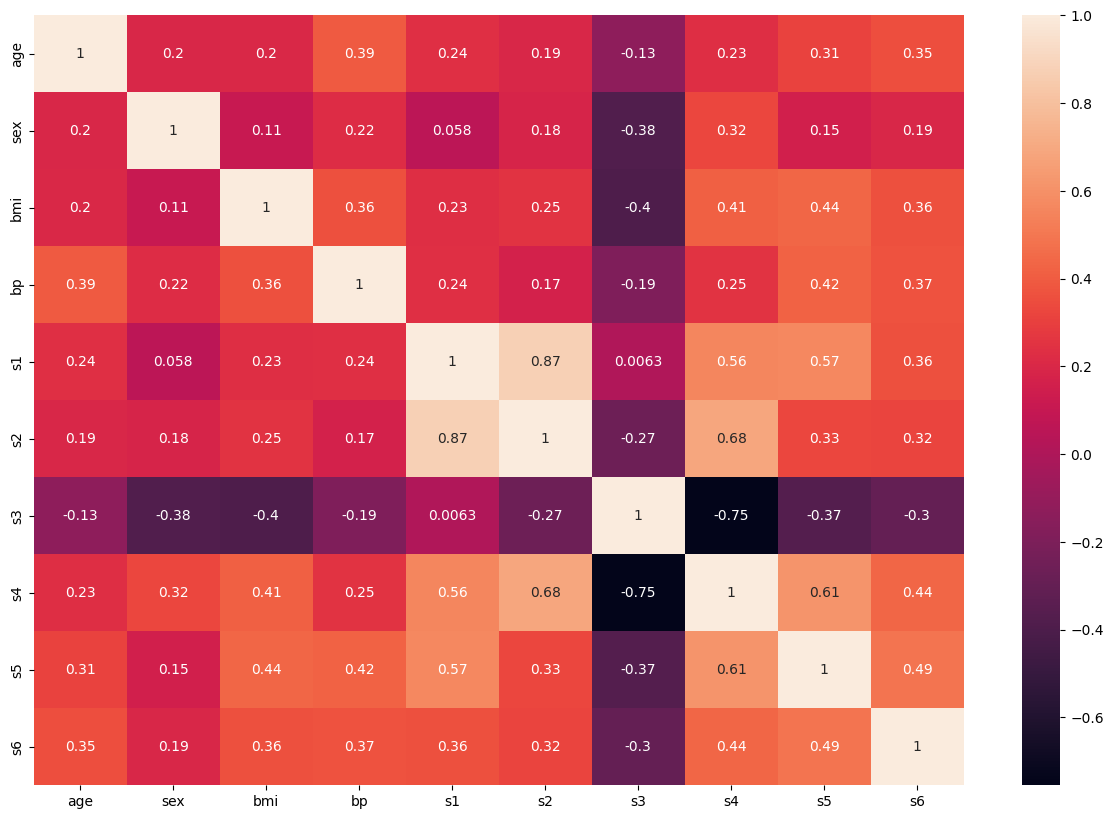

In [84]:
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [85]:
from sklearn.tree import DecisionTreeRegressor
reg=DecisionTreeRegressor()
reg.fit(X_train,y_train)
y_pred=reg.predict(X_test)

In [86]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("MSE:",mse)
print("R2 SCORE:",r2)

MSE: 7699.255639097744
R2 SCORE: -0.2167597720343044


# HYPERPARAMETER TUNING

In [87]:
params={'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
        'splitter':['best', 'random'],
        'max_features':['auto','sqrt','log2'],
        'max_depth': [1,2,3,4,5,10,15,20],     
        }

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()

In [89]:
grid=GridSearchCV(DecisionTreeRegressor(),param_grid=params,cv=cv,refit=True,verbose=3,n_jobs=-1,scoring='neg_mean_squared_error')

In [90]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


c:\DS and ML\venv\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\DS and ML\venv\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
320 fits failed out of a total of 960.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
149 fits failed with the following error:
Traceback (most recent call last):
  File "c:\DS and ML\venv\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\DS and ML\venv\lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\DS and

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error', verbose=3)

In [91]:
y_pred1=grid.predict(X_test)

In [92]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred1)
r2=r2_score(y_test,y_pred1)

print("MSE:",mse)
print("R2 SCORE:",r2)

MSE: 4176.919962390227
R2 SCORE: 0.339896164060991


In [93]:
grid.best_params_

{'criterion': 'poisson',
 'max_depth': 4,
 'max_features': 'log2',
 'splitter': 'best'}

[Text(0.5089285714285714, 0.9, 'x[2] <= 0.005\npoisson = 18.919\nsamples = 309\nvalue = 152.738'),
 Text(0.2857142857142857, 0.7, 'x[3] <= 0.039\npoisson = 13.883\nsamples = 184\nvalue = 121.516'),
 Text(0.39732142857142855, 0.8, 'True  '),
 Text(0.14285714285714285, 0.5, 'x[6] <= -0.027\npoisson = 12.256\nsamples = 156\nvalue = 114.359'),
 Text(0.07142857142857142, 0.3, 'x[8] <= 0.002\npoisson = 11.92\nsamples = 33\nvalue = 153.788'),
 Text(0.03571428571428571, 0.1, 'poisson = 7.803\nsamples = 13\nvalue = 114.077'),
 Text(0.10714285714285714, 0.1, 'poisson = 8.878\nsamples = 20\nvalue = 179.6'),
 Text(0.21428571428571427, 0.3, 'x[2] <= -0.022\npoisson = 10.197\nsamples = 123\nvalue = 103.78'),
 Text(0.17857142857142858, 0.1, 'poisson = 7.908\nsamples = 81\nvalue = 94.247'),
 Text(0.25, 0.1, 'poisson = 12.2\nsamples = 42\nvalue = 122.167'),
 Text(0.42857142857142855, 0.5, 'x[7] <= 0.064\npoisson = 15.826\nsamples = 28\nvalue = 161.393'),
 Text(0.35714285714285715, 0.3, 'x[5] <= -0.041\

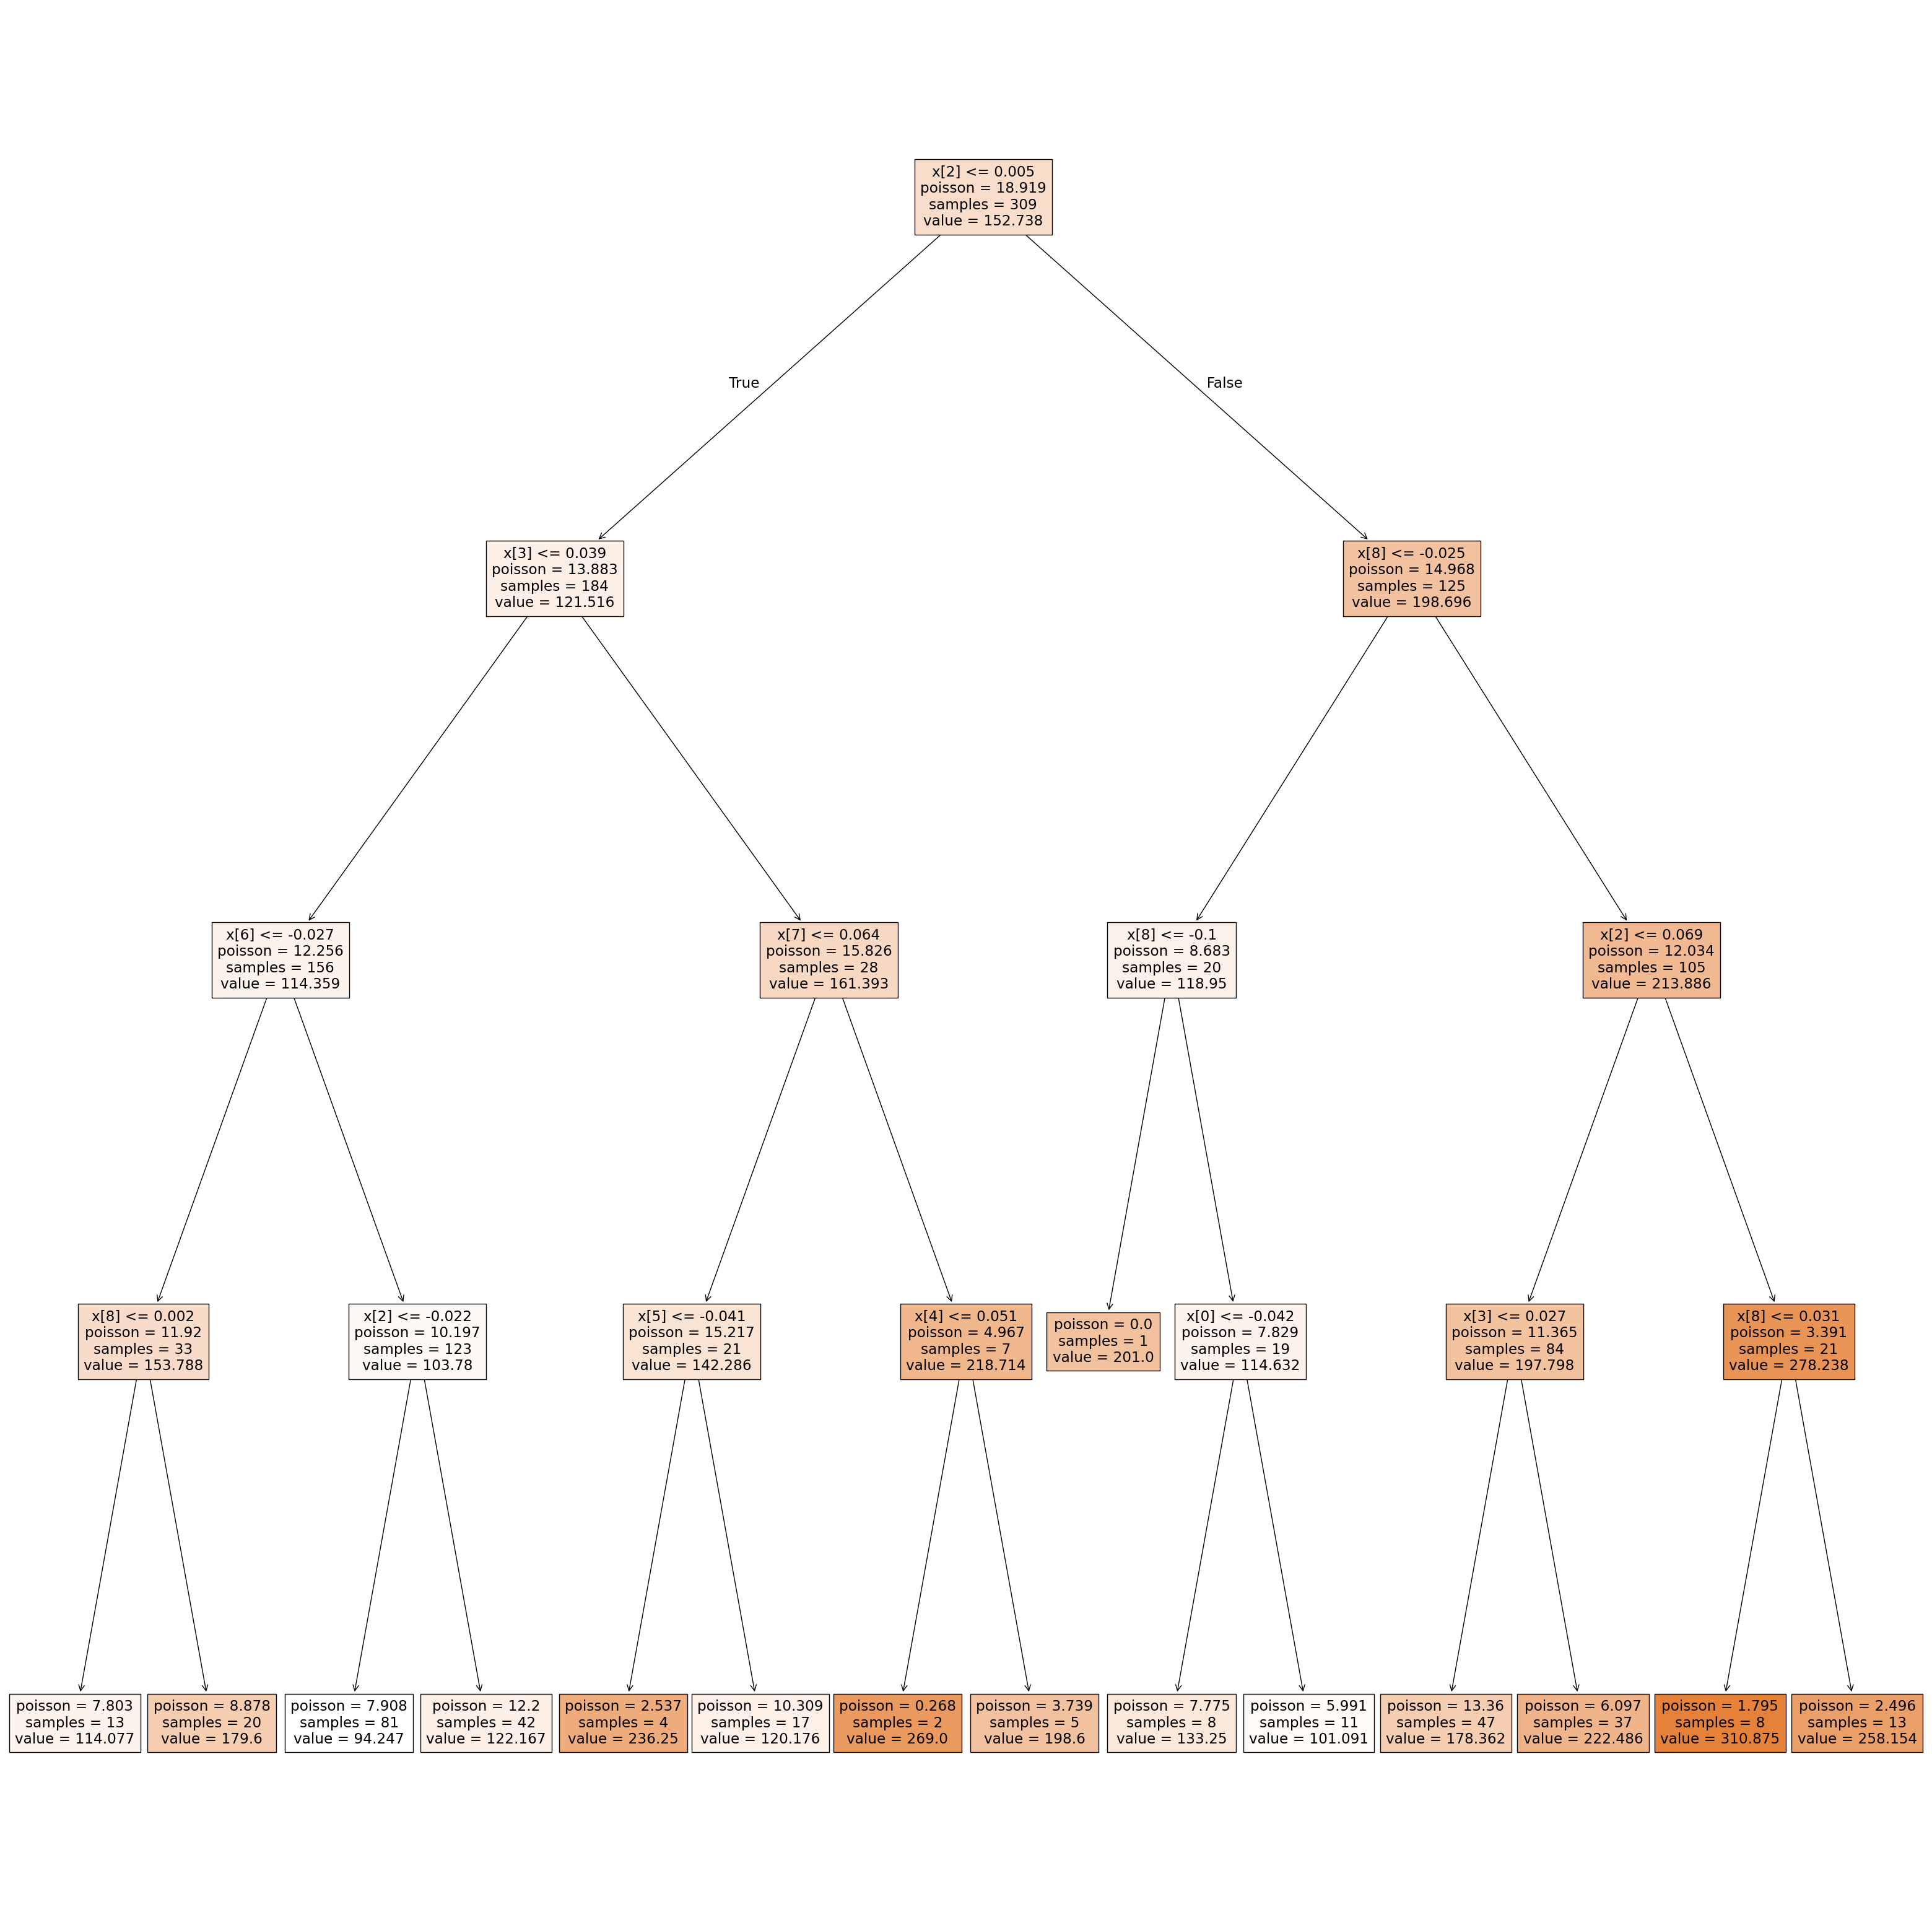

In [94]:
from sklearn import tree
plt.figure(figsize=(40,40))
tree.plot_tree(grid.best_estimator_,filled=True)